[[Model]]
    Model(michaelis_menten)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 16
    # data points      = 10
    # variables        = 2
    chi-square         = 2.69884131
    reduced chi-square = 0.33735516
    Akaike info crit   = -9.09762558
    Bayesian info crit = -8.49245539
    R-squared          = 0.99865205
[[Variables]]
    vmax:  52.6728511 +/- 0.67963689 (1.29%) (init = 50)
    km:    6.81699667 +/- 0.26055286 (3.82%) (init = 5)
[[Correlations]] (unreported correlations are < 0.100)
    C(vmax, km) = +0.8695


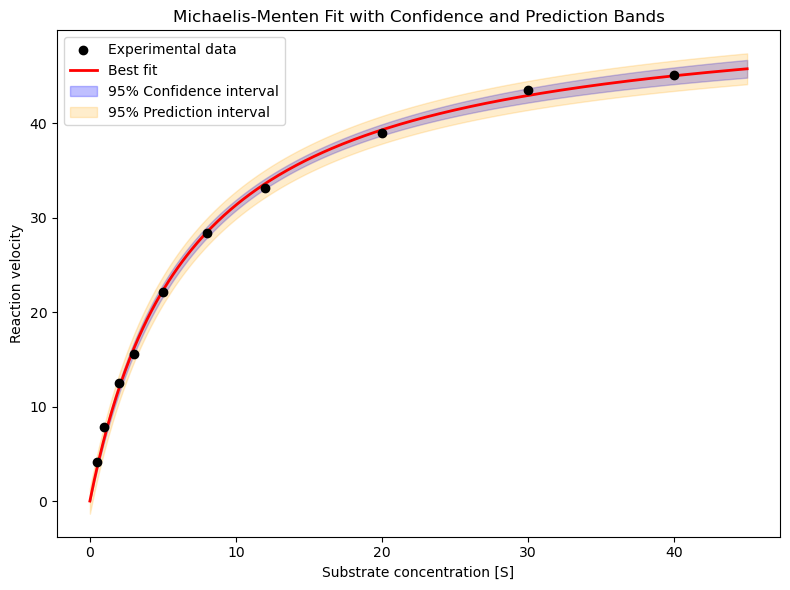

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from lmfit import Model
from scipy.stats import t

# -----------------------------------------------------------------------------
# Example Michaelis-Menten data
# -----------------------------------------------------------------------------

S = np.array([0.5, 1, 2, 3, 5, 8, 12, 20, 30, 40])
v = np.array([4.1, 7.8, 12.5, 15.6, 22.1,
              28.4, 33.1, 38.9, 43.5, 45.1])

n = len(S)

# -----------------------------------------------------------------------------
# Michaelis-Menten model
# -----------------------------------------------------------------------------

def michaelis_menten(S, vmax, km):
    return vmax * S / (km + S)

model = Model(michaelis_menten)

params = model.make_params(
    vmax=50,
    km=5
)

result = model.fit(v, params, S=S)

print(result.fit_report())

# -----------------------------------------------------------------------------
# Smooth curve for plotting
# -----------------------------------------------------------------------------

xfit = np.linspace(0, 45, 300)

yfit = result.eval(S=xfit)

# -----------------------------------------------------------------------------
# Confidence interval from covariance matrix
# -----------------------------------------------------------------------------

cov = result.covar

# fitted parameters
vmax_hat = result.params['vmax'].value
km_hat = result.params['km'].value

# Jacobian-based confidence bands
var_mean = np.zeros_like(xfit)

for i, x in enumerate(xfit):

    # Partial derivatives
    d_vmax = x / (km_hat + x)

    d_km = -vmax_hat * x / (km_hat + x)**2

    J = np.array([d_vmax, d_km])

    var_mean[i] = J @ cov @ J.T

se_mean = np.sqrt(var_mean)

# -----------------------------------------------------------------------------
# Residual variance
# -----------------------------------------------------------------------------

rss = np.sum(result.residual**2)
p = len(result.var_names)
dof = n - p

mse = rss / dof

# -----------------------------------------------------------------------------
# 95% confidence interval
# -----------------------------------------------------------------------------

alpha = 0.05
tval = t.ppf(1 - alpha/2, dof)

ci_upper = yfit + tval * se_mean
ci_lower = yfit - tval * se_mean

# -----------------------------------------------------------------------------
# 95% prediction interval
# -----------------------------------------------------------------------------

se_pred = np.sqrt(se_mean**2 + mse)

pi_upper = yfit + tval * se_pred
pi_lower = yfit - tval * se_pred

# -----------------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    S, v,
    color='black',
    zorder=3,
    label='Experimental data'
)

plt.plot(
    xfit,
    yfit,
    color='red',
    linewidth=2,
    label='Best fit'
)

plt.fill_between(
    xfit,
    ci_lower,
    ci_upper,
    color='blue',
    alpha=0.25,
    label='95% Confidence interval'
)

plt.fill_between(
    xfit,
    pi_lower,
    pi_upper,
    color='orange',
    alpha=0.20,
    label='95% Prediction interval'
)

plt.xlabel("Substrate concentration [S]")
plt.ylabel("Reaction velocity")
plt.title("Michaelis-Menten Fit with Confidence and Prediction Bands")

plt.legend()
plt.tight_layout()
plt.show()



[[Model]]
    Model(line)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 10
    # variables        = 2
    chi-square         = 7.2824e-05
    reduced chi-square = 9.1030e-06
    Akaike info crit   = -114.300456
    Bayesian info crit = -113.695286
    R-squared          = 0.99833085
[[Variables]]
    slope:      0.11099207 +/- 0.00160457 (1.45%) (init = 0.5)
    intercept:  0.02149346 +/- 0.00118215 (5.50%) (init = 0.02)
[[Correlations]] (unreported correlations are < 0.100)
    C(slope, intercept) = -0.5904

Vmax = 46.526
Km   = 5.164


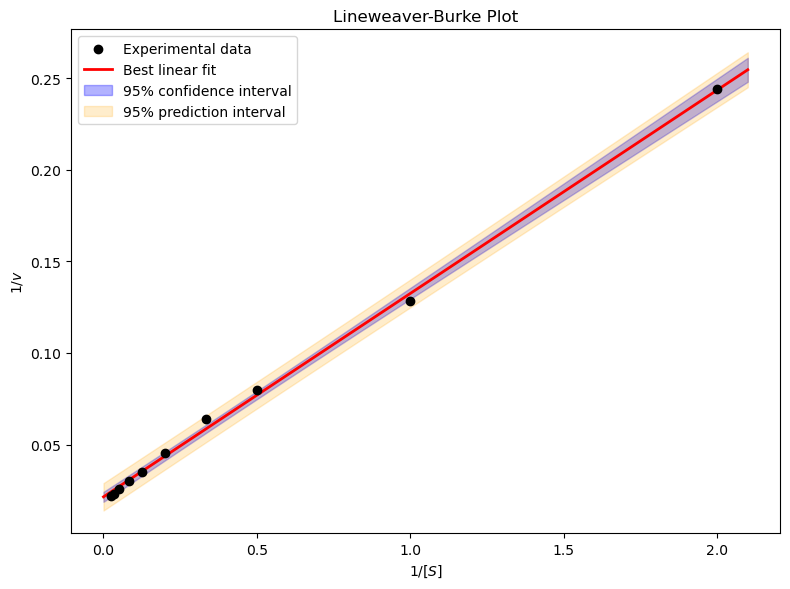

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from lmfit import Model
from scipy.stats import t

# =============================================================================
# Example Michaelis-Menten data
# =============================================================================

S = np.array([0.5, 1, 2, 3, 5, 8, 12, 20, 30, 40])
v = np.array([4.1, 7.8, 12.5, 15.6, 22.1,
              28.4, 33.1, 38.9, 43.5, 45.1])

# =============================================================================
# Transform to Lineweaver-Burke coordinates
# =============================================================================

x = 1 / S
y = 1 / v

n = len(x)

# =============================================================================
# Linear model
# =============================================================================

def line(x, slope, intercept):
    return slope*x + intercept

model = Model(line)

params = model.make_params(
    slope=0.5,
    intercept=0.02
)

result = model.fit(y, params, x=x)

print(result.fit_report())

# =============================================================================
# Extract fit parameters
# =============================================================================

m = result.params["slope"].value
b = result.params["intercept"].value

# Derived kinetic parameters

Vmax = 1/b
Km = m/b

print(f"\nVmax = {Vmax:.3f}")
print(f"Km   = {Km:.3f}")

# =============================================================================
# Generate smooth line
# =============================================================================

xfit = np.linspace(0, x.max()*1.05, 300)

yfit = result.eval(x=xfit)

# =============================================================================
# Confidence interval calculations
# =============================================================================

cov = result.covar

var_mean = np.zeros_like(xfit)

for i, xx in enumerate(xfit):

    jacobian = np.array([xx, 1.0])

    var_mean[i] = jacobian @ cov @ jacobian.T

se_mean = np.sqrt(var_mean)

# =============================================================================
# Residual variance
# =============================================================================

rss = np.sum(result.residual**2)

p = len(result.var_names)

dof = n - p

mse = rss / dof

# =============================================================================
# 95% confidence interval
# =============================================================================

alpha = 0.05

tval = t.ppf(1 - alpha/2, dof)

ci_upper = yfit + tval * se_mean
ci_lower = yfit - tval * se_mean

# =============================================================================
# 95% prediction interval
# =============================================================================

se_pred = np.sqrt(se_mean**2 + mse)

pi_upper = yfit + tval * se_pred
pi_lower = yfit - tval * se_pred

# =============================================================================
# Plot
# =============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    x,
    y,
    color='black',
    zorder=10,
    label='Experimental data'
)

plt.plot(
    xfit,
    yfit,
    color='red',
    lw=2,
    label='Best linear fit'
)

plt.fill_between(
    xfit,
    ci_lower,
    ci_upper,
    color='blue',
    alpha=0.30,
    label='95% confidence interval'
)

plt.fill_between(
    xfit,
    pi_lower,
    pi_upper,
    color='orange',
    alpha=0.20,
    label='95% prediction interval'
)

plt.xlabel(r'$1/[S]$')
plt.ylabel(r'$1/v$')

plt.title('Lineweaver-Burke Plot')

plt.legend()

plt.tight_layout()

plt.show()

## MM Confidence Interval

[[Model]]
    Model(michaelis_menten)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 16
    # data points      = 10
    # variables        = 2
    chi-square         = 2.69884131
    reduced chi-square = 0.33735516
    Akaike info crit   = -9.09762558
    Bayesian info crit = -8.49245539
    R-squared          = 0.99865205
[[Variables]]
    vmax:  52.6728511 +/- 0.67963689 (1.29%) (init = 50)
    km:    6.81699667 +/- 0.26055286 (3.82%) (init = 5)
[[Correlations]] (unreported correlations are < 0.100)
    C(vmax, km) = +0.8695


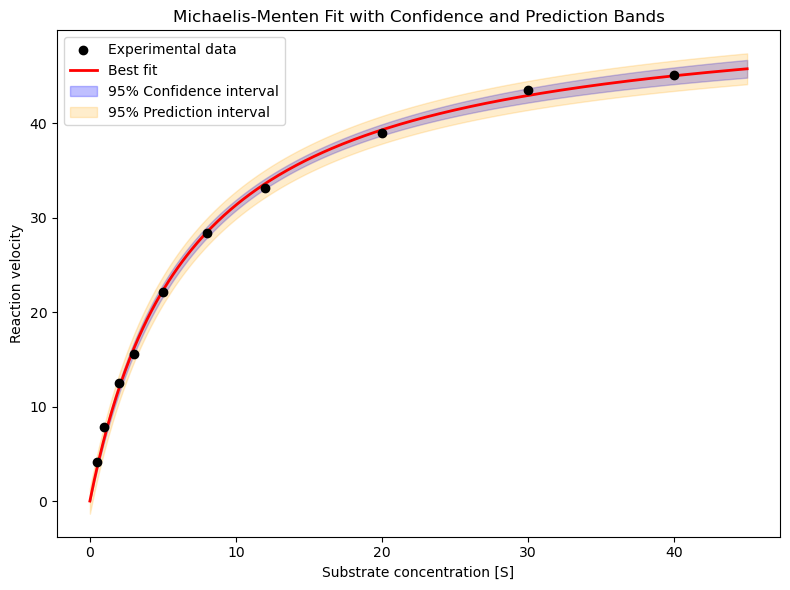

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from lmfit import Model
from scipy.stats import t

# -----------------------------------------------------------------------------
# Example Michaelis-Menten data
# -----------------------------------------------------------------------------

S = np.array([0.5, 1, 2, 3, 5, 8, 12, 20, 30, 40])
v = np.array([4.1, 7.8, 12.5, 15.6, 22.1,
              28.4, 33.1, 38.9, 43.5, 45.1])

n = len(S)

# -----------------------------------------------------------------------------
# Michaelis-Menten model
# -----------------------------------------------------------------------------

def michaelis_menten(S, vmax, km):
    return vmax * S / (km + S)

model = Model(michaelis_menten)

params = model.make_params(
    vmax=50,
    km=5
)

result = model.fit(v, params, S=S)

print(result.fit_report())

# -----------------------------------------------------------------------------
# Smooth curve for plotting
# -----------------------------------------------------------------------------

xfit = np.linspace(0, 45, 300) # Array of x-values for smooth curve
yfit = result.eval(S=xfit)     # Evaluate the fitted model at each x-value

# -----------------------------------------------------------------------------
# Confidence interval from covariance matrix
# -----------------------------------------------------------------------------

cov = result.covar # covariance matrix of the fitted parameters

# fitted parameters
vmax_hat = result.params['vmax'].value      # Fitted value of Vmax
km_hat = result.params['km'].value          # Fitted value of Km

# Jacobian-based confidence bands
var_mean = np.zeros_like(xfit)
for i, x in enumerate(xfit): 
    # Partial derivatives
    d_vmax = x / (km_hat + x)               # Partial derivative with respect to Vmax
    d_km = -vmax_hat * x / (km_hat + x)**2  # Partial derivative with respect to Km
    J = np.array([d_vmax, d_km])            # Jacobian for Michaelis-Menten model
    var_mean[i] = J @ cov @ J.T             # Jacobian-based confidence bands
se_mean = np.sqrt(var_mean)           # The standard error of the predicted mean response at each value of xfit

# -----------------------------------------------------------------------------
# Residual variance
# -----------------------------------------------------------------------------

rss = np.sum(result.residual**2)
p = len(result.var_names)
dof = n - p

mse = rss / dof

# -----------------------------------------------------------------------------
# 95% confidence interval
# -----------------------------------------------------------------------------

alpha = 0.05
tval = t.ppf(1 - alpha/2, dof)

ci_upper = yfit + tval * se_mean
ci_lower = yfit - tval * se_mean

# -----------------------------------------------------------------------------
# 95% prediction interval
# -----------------------------------------------------------------------------

se_pred = np.sqrt(se_mean**2 + mse)

pi_upper = yfit + tval * se_pred
pi_lower = yfit - tval * se_pred

# -----------------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    S, v,
    color='black',
    zorder=3,
    label='Experimental data'
)

plt.plot(
    xfit,
    yfit,
    color='red',
    linewidth=2,
    label='Best fit'
)

plt.fill_between(
    xfit,
    ci_lower,
    ci_upper,
    color='blue',
    alpha=0.25,
    label='95% Confidence interval'
)

plt.fill_between(
    xfit,
    pi_lower,
    pi_upper,
    color='orange',
    alpha=0.20,
    label='95% Prediction interval'
)

plt.xlabel("Substrate concentration [S]")
plt.ylabel("Reaction velocity")
plt.title("Michaelis-Menten Fit with Confidence and Prediction Bands")

plt.legend()
plt.tight_layout()
plt.show()

## LB Confidence Interval

[[Model]]
    Model(line)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 10
    # variables        = 2
    chi-square         = 7.2824e-05
    reduced chi-square = 9.1030e-06
    Akaike info crit   = -114.300456
    Bayesian info crit = -113.695286
    R-squared          = 0.99833085
[[Variables]]
    slope:      0.11099207 +/- 0.00160457 (1.45%) (init = 0.5)
    intercept:  0.02149346 +/- 0.00118215 (5.50%) (init = 0.02)
[[Correlations]] (unreported correlations are < 0.100)
    C(slope, intercept) = -0.5904

Vmax = 46.526
Km   = 5.164


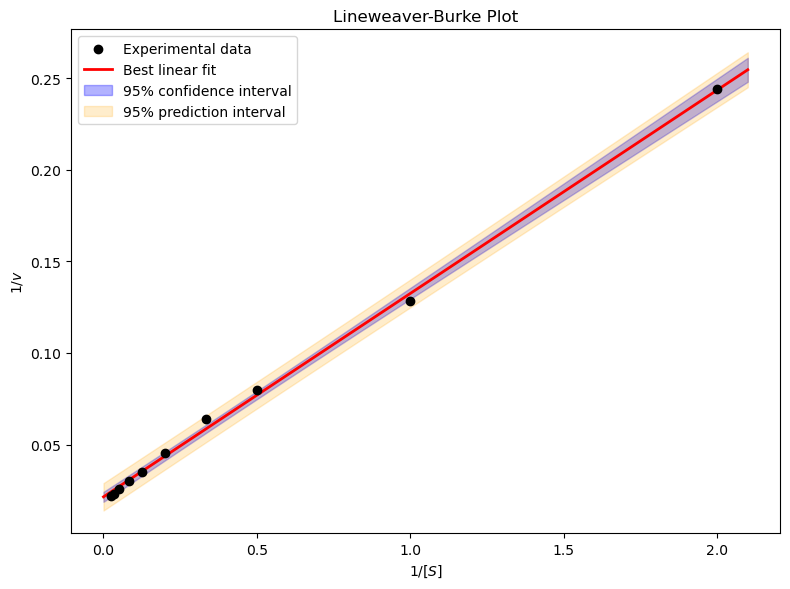

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from lmfit import Model
from scipy.stats import t

# =============================================================================
# Example Michaelis-Menten data
# =============================================================================

S = np.array([0.5, 1, 2, 3, 5, 8, 12, 20, 30, 40])
v = np.array([4.1, 7.8, 12.5, 15.6, 22.1,
              28.4, 33.1, 38.9, 43.5, 45.1])

# =============================================================================
# Transform to Lineweaver-Burke coordinates
# =============================================================================

x = 1 / S
y = 1 / v

n = len(x)

# =============================================================================
# Linear model
# =============================================================================

def line(x, slope, intercept):
    return slope*x + intercept

model = Model(line)

params = model.make_params(
    slope=0.5,
    intercept=0.02
)

result = model.fit(y, params, x=x)

print(result.fit_report())

# =============================================================================
# Extract fit parameters
# =============================================================================

m = result.params["slope"].value
b = result.params["intercept"].value

# Derived kinetic parameters

Vmax = 1/b
Km = m/b

print(f"\nVmax = {Vmax:.3f}")
print(f"Km   = {Km:.3f}")

# =============================================================================
# Generate smooth line
# =============================================================================

xfit = np.linspace(0, x.max()*1.05, 300)

yfit = result.eval(x=xfit)

# =============================================================================
# Confidence interval calculations
# =============================================================================

cov = result.covar

var_mean = np.zeros_like(xfit)

for i, xx in enumerate(xfit):

    jacobian = np.array([xx, 1.0]) # Jacobian for linear model

    var_mean[i] = jacobian @ cov @ jacobian.T # Jacobian-based confidence bands

se_mean = np.sqrt(var_mean)

# =============================================================================
# Residual variance
# =============================================================================

rss = np.sum(result.residual**2)

p = len(result.var_names)

dof = n - p

mse = rss / dof

# =============================================================================
# 95% confidence interval
# =============================================================================

alpha = 0.05

tval = t.ppf(1 - alpha/2, dof)

ci_upper = yfit + tval * se_mean
ci_lower = yfit - tval * se_mean

# =============================================================================
# 95% prediction interval
# =============================================================================

se_pred = np.sqrt(se_mean**2 + mse)

pi_upper = yfit + tval * se_pred
pi_lower = yfit - tval * se_pred

# =============================================================================
# Plot
# =============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    x,
    y,
    color='black',
    zorder=10,
    label='Experimental data'
)

plt.plot(
    xfit,
    yfit,
    color='red',
    lw=2,
    label='Best linear fit'
)

plt.fill_between(
    xfit,
    ci_lower,
    ci_upper,
    color='blue',
    alpha=0.30,
    label='95% confidence interval'
)

plt.fill_between(
    xfit,
    pi_lower,
    pi_upper,
    color='orange',
    alpha=0.20,
    label='95% prediction interval'
)

plt.xlabel(r'$1/[S]$')
plt.ylabel(r'$1/v$')

plt.title('Lineweaver-Burke Plot')

plt.legend()

plt.tight_layout()

plt.show()